# Clasificación de Señas Dinámicas en LSM (Lenguaje de Señas Mexicano)

Este notebook implementa un pipeline para clasificar **señas dinámicas** del abecedario de LSM
usando **MediaPipe Hands** para extracción de landmarks y un modelo de machine learning para clasificación.

## Categorías
Las señas dinámicas a clasificar son: **J, K, Ñ, Q, X, Z**

## Estrategia
A diferencia de las señas estáticas (imágenes), las señas dinámicas son **videos**.  
El pipeline es:
1. Leer cada video cuadro a cuadro
2. Extraer landmarks de mano con MediaPipe en cada cuadro
3. Agregar los landmarks a través del tiempo para crear un vector de características por video
4. Entrenar un clasificador con esas características
5. Evaluar con el conjunto de prueba

---
## PASO 1. Importar librerías

In [24]:
# !pip install mediapipe -q

In [25]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

print("MediaPipe versión:", mp.__version__)
print("Librerías cargadas correctamente")

MediaPipe versión: 0.10.9
Librerías cargadas correctamente


---
## PASO 2. Configuración del dataset

In [26]:
# ============================================================
# CONFIGURACIÓN DE RUTAS Y PARÁMETROS
# ============================================================

# Ruta base del dataset de señas dinámicas
DATASET_BASE = "./datasets/MSL-dynamic-signs"
TRAIN_PATH   = os.path.join(DATASET_BASE, "train")
TEST_PATH    = os.path.join(DATASET_BASE, "test")

# Categorías a clasificar
CLASSES = ["J", "K", "Ñ", "Q", "X", "Z"]

# Número de cuadros a samplear por video
MAX_FRAMES = 30  # Tomamos hasta 30 cuadros por video para normalizar la longitud

# Número de landmarks de la mano (MediaPipe: 21 puntos x 3 coordenadas = 63)
N_LANDMARKS = 21
N_COORDS    = 3   # x, y, z
N_LM_FEATS  = N_LANDMARKS * N_COORDS  # 63 features por frame

print(f"Dataset: {DATASET_BASE}")
print(f"Clases: {CLASSES}")
print(f"Max frames por video: {MAX_FRAMES}")
print(f"Features por frame: {N_LM_FEATS}")
print(f"Train path existe: {os.path.exists(TRAIN_PATH)}")
print(f"Test path existe: {os.path.exists(TEST_PATH)}")

Dataset: ./datasets/MSL-dynamic-signs
Clases: ['J', 'K', 'Ñ', 'Q', 'X', 'Z']
Max frames por video: 30
Features por frame: 63
Train path existe: True
Test path existe: True


---
## PASO 3. Explorar el dataset

In [27]:
# ============================================================
# EXPLORACIÓN DEL DATASET
# ============================================================

def extract_label_from_filename(filename):
    """
    Extrae la etiqueta (letra) del nombre del archivo.
    Formato: S{num}-{LETRA}-{tipo}-{num}.mp4
    Ejemplos:
      S1-J-frontal-1.mp4     -> J
      S19-K-Frontal.1.mp4   -> K
      S1-Ñ-frontal-1.mp4    -> Ñ
    """
    parts = os.path.basename(filename).split('-')
    if len(parts) >= 2:
        return parts[1].upper()
    return None


def scan_split(split_path):
    """Escanea una carpeta (train o test) y devuelve un DataFrame con path y label."""
    records = []
    for fpath in glob(os.path.join(split_path, "*.mp4")):
        label = extract_label_from_filename(fpath)
        if label in CLASSES:
            records.append({"path": fpath, "filename": os.path.basename(fpath), "label": label})
    return pd.DataFrame(records)


df_train_raw = scan_split(TRAIN_PATH)
df_test_raw  = scan_split(TEST_PATH)

print("=== TRAIN ===")
print(df_train_raw["label"].value_counts().sort_index())
print(f"Total videos: {len(df_train_raw)}\n")

print("=== TEST ===")
print(df_test_raw["label"].value_counts().sort_index())
print(f"Total videos: {len(df_test_raw)}")

=== TRAIN ===
label
J    92
K    95
Q    91
X    94
Z    93
Ñ    97
Name: count, dtype: int64
Total videos: 562

=== TEST ===
label
J    10
K    10
Q    10
X    10
Z    10
Ñ    10
Name: count, dtype: int64
Total videos: 60


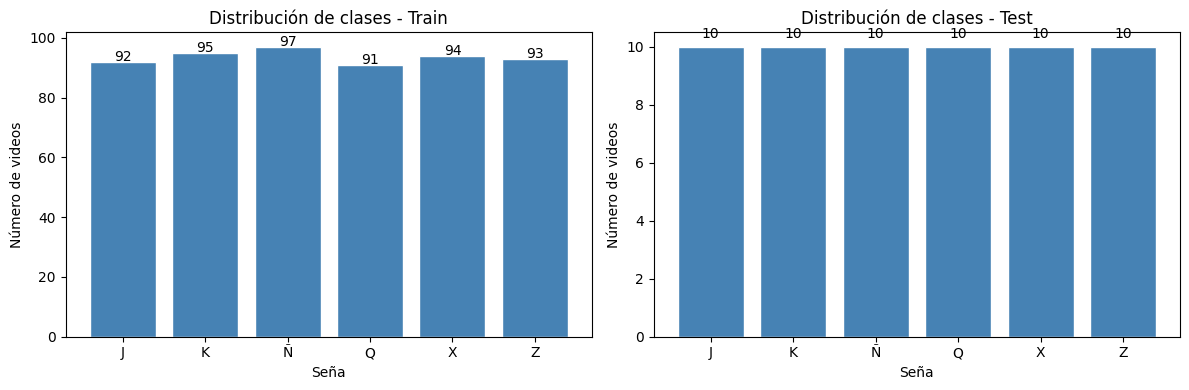

In [28]:
# ============================================================
# VISUALIZAR DISTRIBUCIÓN DE CLASES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [df_train_raw, df_test_raw], ["Train", "Test"]):
    counts = df["label"].value_counts().reindex(CLASSES, fill_value=0)
    ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribución de clases - {title}")
    ax.set_xlabel("Seña")
    ax.set_ylabel("Número de videos")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

---
## PASO 4. Configurar MediaPipe y función de extracción

In [29]:
# ============================================================
# PASO 4. CONFIGURAR MEDIAPIPE HANDS
# ============================================================

mp_hands    = mp.solutions.hands
mp_drawing  = mp.solutions.drawing_utils

def extract_landmarks_from_video(video_path, max_frames=MAX_FRAMES):
    """
    Lee un video y extrae landmarks de MediaPipe Hands en cada cuadro.

    Estrategia de muestreo:
      - Si el video tiene <= max_frames cuadros, usa todos.
      - Si tiene más, samplea max_frames cuadros uniformemente.

    Si MediaPipe no detecta mano en un cuadro, rellena con ceros.

    Devuelve:
      - sequence: array (max_frames, 63) con los landmarks por cuadro
      - detected_frames: número de cuadros donde se detectó mano
    """
    cap = cv2.VideoCapture(video_path)
    all_frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        all_frames.append(frame)

    cap.release()

    total = len(all_frames)
    if total == 0:
        return None, 0

    # Samplear uniformemente
    if total <= max_frames:
        selected = all_frames
    else:
        indices  = np.linspace(0, total - 1, max_frames, dtype=int)
        selected = [all_frames[i] for i in indices]

    sequence = []
    detected = 0

    with mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=1,
        min_detection_confidence=0.4,
        min_tracking_confidence=0.4
    ) as hands:
        for frame in selected:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = hands.process(rgb)

            if results.multi_hand_landmarks:
                lm = results.multi_hand_landmarks[0]
                flat = []
                for point in lm.landmark:
                    flat.extend([point.x, point.y, point.z])
                sequence.append(flat)
                detected += 1
            else:
                sequence.append([0.0] * N_LM_FEATS)  # Relleno con ceros si no se detecta

    # Pad hasta max_frames si el video tenía menos cuadros
    while len(sequence) < max_frames:
        sequence.append([0.0] * N_LM_FEATS)

    return np.array(sequence), detected  # shape: (max_frames, 63)


print("Función de extracción de landmarks lista")
print(f"Cada video generará un array de shape ({MAX_FRAMES}, {N_LM_FEATS})")

Función de extracción de landmarks lista
Cada video generará un array de shape (30, 63)


---
## PASO 5. Ingeniería de características temporales

Para convertir la secuencia temporal (T cuadros x 63 coords) en un vector fijo,
calculamos estadísticas de agregación sobre el tiempo:

| Estadística | Descripción |
|-------------|-------------|
| Mean        | Posición promedio de cada landmark |
| Std         | Variabilidad / rango de movimiento |
| Min / Max   | Extremos del movimiento |
| Velocity (diff mean) | Velocidad promedio de cada coordenada |
| Velocity (diff std)  | Variabilidad en la velocidad |

Esto captura **cuánto se mueve** la mano y **cómo** se mueve, que es crucial para señas dinámicas.

In [30]:
# ============================================================
# PASO 5. INGENIERÍA DE CARACTERÍSTICAS TEMPORALES
# ============================================================

def sequence_to_features(sequence):
    """
    Convierte una secuencia (max_frames, 63) en un vector de features 1D.

    Features calculadas:
      - mean, std, min, max de cada coordenada (4 x 63 = 252)
      - mean y std de las diferencias frame-a-frame (velocidades) (2 x 63 = 126)
    Total: 378 features
    """
    seq = np.array(sequence)  # (T, 63)

    # Estadísticas de posición
    mean_pos = seq.mean(axis=0)     # (63,)
    std_pos  = seq.std(axis=0)      # (63,)
    min_pos  = seq.min(axis=0)      # (63,)
    max_pos  = seq.max(axis=0)      # (63,)

    # Velocidad: diferencias frame-a-frame
    diff = np.diff(seq, axis=0)     # (T-1, 63)
    mean_vel = diff.mean(axis=0)    # (63,)
    std_vel  = diff.std(axis=0)     # (63,)

    return np.concatenate([mean_pos, std_pos, min_pos, max_pos, mean_vel, std_vel])


FEATURE_DIM = 4 * N_LM_FEATS + 2 * N_LM_FEATS  # 6 * 63 = 378
print(f"Dimensión del vector de features por video: {FEATURE_DIM}")

Dimensión del vector de features por video: 378


---
## PASO 6. Extraer features del conjunto de entrenamiento

In [31]:
# ============================================================
# PASO 6. PROCESAR VIDEOS DE TRAIN
# ============================================================

def process_split(df, split_name="split"):
    """
    Procesa todos los videos en un DataFrame y extrae features.
    Devuelve X (features), y (labels) y stats de detección.
    """
    X_list      = []
    y_list      = []
    skipped     = []
    detection_rates = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Procesando {split_name}"):
        sequence, detected = extract_landmarks_from_video(row["path"])

        if sequence is None:
            skipped.append(row["path"])
            continue

        detection_rate = detected / MAX_FRAMES
        detection_rates.append(detection_rate)

        features = sequence_to_features(sequence)
        X_list.append(features)
        y_list.append(row["label"])

    X = np.array(X_list)
    y = np.array(y_list)

    print(f"\n{split_name}: {len(X)} videos procesados, {len(skipped)} omitidos")
    if detection_rates:
        print(f"Tasa de detección promedio: {np.mean(detection_rates):.2%}")

    return X, y


X_train, y_train = process_split(df_train_raw, "TRAIN")
print(f"\nShape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Distribución train: {dict(zip(*np.unique(y_train, return_counts=True)))}")

Procesando TRAIN: 100%|██████████| 562/562 [04:58<00:00,  1.88it/s]


TRAIN: 561 videos procesados, 1 omitidos
Tasa de detección promedio: 96.70%

Shape X_train: (561, 378)
Shape y_train: (561,)
Distribución train: {np.str_('J'): np.int64(92), np.str_('K'): np.int64(95), np.str_('Q'): np.int64(90), np.str_('X'): np.int64(94), np.str_('Z'): np.int64(93), np.str_('Ñ'): np.int64(97)}


---
## PASO 7. Extraer features del conjunto de prueba

In [32]:
# ============================================================
# PASO 7. PROCESAR VIDEOS DE TEST
# ============================================================

X_test, y_test = process_split(df_test_raw, "TEST")
print(f"\nShape X_test: {X_test.shape}")
print(f"Shape y_test: {y_test.shape}")
print(f"Distribución test: {dict(zip(*np.unique(y_test, return_counts=True)))}")

Procesando TEST: 100%|██████████| 60/60 [00:35<00:00,  1.71it/s]


TEST: 60 videos procesados, 0 omitidos
Tasa de detección promedio: 96.94%

Shape X_test: (60, 378)
Shape y_test: (60,)
Distribución test: {np.str_('J'): np.int64(10), np.str_('K'): np.int64(10), np.str_('Q'): np.int64(10), np.str_('X'): np.int64(10), np.str_('Z'): np.int64(10), np.str_('Ñ'): np.int64(10)}


---
## PASO 8. Normalizar features

In [33]:
# ============================================================
# PASO 8. NORMALIZACIÓN
# ============================================================

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Normalización completada")
print(f"X_train_sc shape: {X_train_sc.shape}")
print(f"X_test_sc  shape: {X_test_sc.shape}")

Normalización completada
X_train_sc shape: (561, 378)
X_test_sc  shape: (60, 378)


---
## PASO 9. Entrenar modelos

Probamos tres clasificadores clásicos:
- **Random Forest**: robusto, sin necesidad de normalización (pero la usamos de igual forma)
- **SVM con kernel RBF**: bueno para datos de alta dimensionalidad
- **Gradient Boosting**: potente ensamble de árboles

In [34]:
# ============================================================
# PASO 9. ENTRENAR MODELOS
# ============================================================

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        C=10.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )
}

results = {}

for name, clf in models.items():
    print(f"\nEntrenando {name}...")
    clf.fit(X_train_sc, y_train)

    y_pred_train = clf.predict(X_train_sc)
    y_pred_test  = clf.predict(X_test_sc)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test,  y_pred_test)
    f1_test   = f1_score(y_test, y_pred_test, average="macro", zero_division=0)

    results[name] = {
        "model":      clf,
        "y_pred":     y_pred_test,
        "acc_train":  acc_train,
        "acc_test":   acc_test,
        "f1_macro":   f1_test
    }

    print(f"  Accuracy train : {acc_train:.4f}")
    print(f"  Accuracy test  : {acc_test:.4f}")
    print(f"  F1-macro test  : {f1_test:.4f}")

print("\n✅ Todos los modelos entrenados")


Entrenando Random Forest...
  Accuracy train : 1.0000
  Accuracy test  : 0.9333
  F1-macro test  : 0.9327

Entrenando SVM (RBF)...
  Accuracy train : 1.0000
  Accuracy test  : 0.9333
  F1-macro test  : 0.9325

Entrenando Gradient Boosting...
  Accuracy train : 1.0000
  Accuracy test  : 0.9333
  F1-macro test  : 0.9340

✅ Todos los modelos entrenados


---
## PASO 10. Comparar modelos

In [35]:
# ============================================================
# PASO 10. TABLA DE COMPARACIÓN DE MODELOS
# ============================================================

comparison_data = [
    {
        "Modelo": name,
        "Acc Train": f"{r['acc_train']:.4f}",
        "Acc Test":  f"{r['acc_test']:.4f}",
        "F1-macro":  f"{r['f1_macro']:.4f}"
    }
    for name, r in results.items()
]

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

# Identificar mejor modelo por F1-macro
best_name = max(results, key=lambda k: results[k]["f1_macro"])
print(f"\n🏆 Mejor modelo: {best_name} (F1-macro = {results[best_name]['f1_macro']:.4f})")

           Modelo Acc Train Acc Test F1-macro
    Random Forest    1.0000   0.9333   0.9327
        SVM (RBF)    1.0000   0.9333   0.9325
Gradient Boosting    1.0000   0.9333   0.9340

🏆 Mejor modelo: Gradient Boosting (F1-macro = 0.9340)


---
## PASO 11. Análisis detallado del mejor modelo

In [36]:
# ============================================================
# PASO 11. REPORTE DEL MEJOR MODELO
# ============================================================

best_result = results[best_name]
y_pred_best = best_result["y_pred"]

print(f"=== Reporte de clasificación: {best_name} ===")
print(classification_report(y_test, y_pred_best, target_names=sorted(CLASSES), zero_division=0))

=== Reporte de clasificación: Gradient Boosting ===
              precision    recall  f1-score   support

           J       1.00      1.00      1.00        10
           K       0.71      1.00      0.83        10
           Q       1.00      0.70      0.82        10
           X       1.00      1.00      1.00        10
           Z       1.00      0.90      0.95        10
           Ñ       1.00      1.00      1.00        10

    accuracy                           0.93        60
   macro avg       0.95      0.93      0.93        60
weighted avg       0.95      0.93      0.93        60



---
## PASO 12. Matriz de confusión

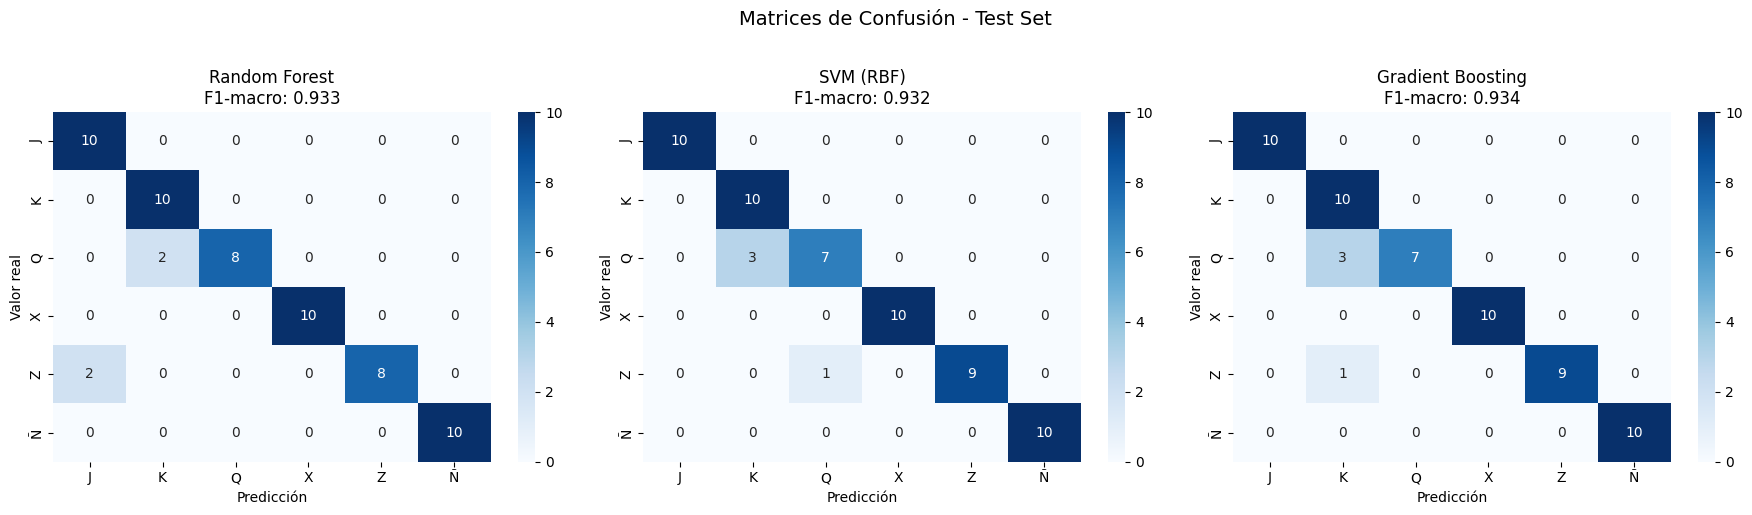

In [37]:
# ============================================================
# PASO 12. MATRICES DE CONFUSIÓN
# ============================================================

fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))

if len(models) == 1:
    axes = [axes]

class_labels = sorted(CLASSES)

for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result["y_pred"], labels=class_labels)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax
    )
    ax.set_title(f"{name}\nF1-macro: {result['f1_macro']:.3f}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")

plt.suptitle("Matrices de Confusión - Test Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## PASO 13. Importancia de características (Random Forest)

In [38]:
# ============================================================
# PASO 13. IMPORTANCIA DE CARACTERÍSTICAS (RF)
# ============================================================

rf_model = results["Random Forest"]["model"]

stat_names = ["mean", "std", "min", "max", "vel_mean", "vel_std"]
feature_names = []
for stat in stat_names:
    for lm_idx in range(N_LANDMARKS):
        for coord in ["x", "y", "z"]:
            feature_names.append(f"{stat}_lm{lm_idx}_{coord}")

importances = pd.DataFrame({
    "feature":    feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 20 features más importantes:")
print(importances.head(20).to_string(index=False))

importances["stat"] = importances["feature"].apply(lambda x: x.split("_")[0])
stat_importance = importances.groupby("stat")["importance"].sum().sort_values(ascending=False)
print("\nImportancia agrupada por tipo de estadística:")
print(stat_importance.to_string())

Top 20 features más importantes:
        feature  importance
      max_lm0_y    0.020092
     mean_lm9_z    0.018329
     mean_lm5_z    0.017286
      std_lm8_y    0.015474
     mean_lm0_z    0.013815
     mean_lm0_y    0.013043
     mean_lm6_z    0.012756
vel_mean_lm17_z    0.012617
  vel_std_lm8_y    0.010866
vel_mean_lm13_z    0.010652
      min_lm5_z    0.010530
      min_lm6_z    0.010352
    mean_lm20_y    0.009705
      max_lm1_y    0.009666
     max_lm13_y    0.009368
      std_lm7_y    0.008944
     max_lm17_y    0.008503
    mean_lm13_z    0.008141
 vel_std_lm15_y    0.007959
     mean_lm7_z    0.007667

Importancia agrupada por tipo de estadística:
stat
vel     0.317011
mean    0.215284
std     0.184039
max     0.181119
min     0.102546


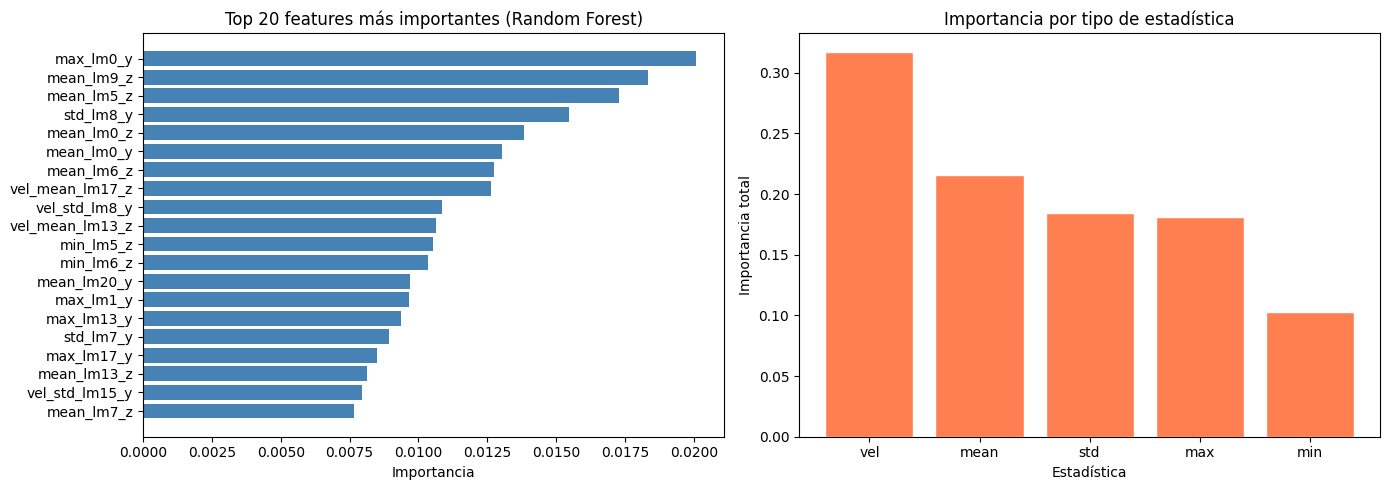

In [39]:
# ============================================================
# VISUALIZAR TOP FEATURES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top20 = importances.head(20)
axes[0].barh(top20["feature"][::-1], top20["importance"][::-1], color="steelblue")
axes[0].set_title("Top 20 features más importantes (Random Forest)")
axes[0].set_xlabel("Importancia")

axes[1].bar(stat_importance.index, stat_importance.values, color="coral", edgecolor="white")
axes[1].set_title("Importancia por tipo de estadística")
axes[1].set_xlabel("Estadística")
axes[1].set_ylabel("Importancia total")

plt.tight_layout()
plt.show()

---
## PASO 14. Análisis de errores

In [40]:
# ============================================================
# PASO 14. ANÁLISIS DE ERRORES
# ============================================================

y_pred_best = results[best_name]["y_pred"]

pred_df = pd.DataFrame({
    "filename": df_test_raw["filename"].values[:len(y_test)],
    "true":     y_test,
    "pred":     y_pred_best
})

errors = pred_df[pred_df["true"] != pred_df["pred"]]
print(f"Total errores: {len(errors)} / {len(pred_df)}")
print(f"\nVideos mal clasificados:")
if len(errors) > 0:
    print(errors.to_string(index=False))
else:
    print("¡Ningún error! Clasificación perfecta.")

Total errores: 4 / 60

Videos mal clasificados:
           filename true pred
S20-Q-Frontal.2.mp4    Q    K
S20-Z-Frontal.5.mp4    Z    K
S21-Q-frontal-1.mp4    Q    K
S21-Q-frontal-2.mp4    Q    K


---
## PASO 15. Guardar resultados

In [41]:
# ============================================================
# PASO 15. GUARDAR RESULTADOS
# ============================================================

pred_df.to_csv("predictions_dynamic_signs.csv", index=False)
print("Predicciones guardadas en: predictions_dynamic_signs.csv")

print("\n=== RESUMEN FINAL ===")
print(df_comparison.to_string(index=False))
print(f"\n🏆 Mejor modelo: {best_name}")
print(f"   Accuracy test  : {results[best_name]['acc_test']:.4f}")
print(f"   F1-macro test  : {results[best_name]['f1_macro']:.4f}")

Predicciones guardadas en: predictions_dynamic_signs.csv

=== RESUMEN FINAL ===
           Modelo Acc Train Acc Test F1-macro
    Random Forest    1.0000   0.9333   0.9327
        SVM (RBF)    1.0000   0.9333   0.9325
Gradient Boosting    1.0000   0.9333   0.9340

🏆 Mejor modelo: Gradient Boosting
   Accuracy test  : 0.9333
   F1-macro test  : 0.9340


---
## Justificación de la métrica principal

Usamos **F1-Score macro** como métrica principal por las siguientes razones:

1. **Desbalance potencial**: el dataset tiene distintos números de videos por clase y por sujeto.
   El F1-macro trata cada clase con igual peso, sin importar su frecuencia.

2. **Relevancia semántica**: en el contexto de la comunicación con señas, confundir cualquier
   seña es igualmente problemático, sin importar cuán frecuente es esa clase en el dataset.

3. **Complementariedad**: reportamos también el Accuracy y la matriz de confusión para
   identificar pares específicos de clases que le cuestan más al modelo.

### Particularidades de las señas dinámicas

Las señas **J** y **Z** son trazados en el aire (como las letras), mientras que **K**, **Q**, **X**
y **Ñ** tienen movimientos específicos de la mano. El modelo necesita capturar tanto la
forma de la mano (posición de landmarks) como el **movimiento** (velocidades y variabilidad temporal).

---
---
## PASO 16. 🎯 Predecir sobre un video a elegir

Usa el mejor modelo entrenado para clasificar **cualquier video MP4** que elijas.

**Dos opciones:**
- **16A** → Diálogo gráfico para seleccionar el archivo (recomendado en Jupyter local)
- **16B** → Escribir la ruta manualmente (útil si el diálogo no funciona)

La celda muestra:
- La seña predicha
- Las probabilidades/scores de cada clase (barra horizontal)
- Miniaturas de cuadros del video con los landmarks dibujados

In [42]:
# ============================================================
# PASO 16 – FUNCIÓN DE PREDICCIÓN
# ============================================================

def predict_video_file(video_path, model, scaler, classes=CLASSES):
    """
    Clasifica un video MP4 usando el modelo entrenado.

    Devuelve:
      predicted_label  : str   – clase predicha
      probabilities    : dict  – clase -> probabilidad (o score normalizado)
      detection_rate   : float – fracción de cuadros con mano detectada
      frames_with_lm   : list  – cuadros RGB con landmarks dibujados
    """
    # 1. Extraer landmarks
    sequence, detected = extract_landmarks_from_video(video_path)
    if sequence is None:
        raise ValueError(f"No se pudieron leer cuadros del video: {video_path}")

    detection_rate = detected / MAX_FRAMES

    # 2. Vectorizar + normalizar
    features    = sequence_to_features(sequence).reshape(1, -1)
    features_sc = scaler.transform(features)

    # 3. Predecir
    predicted_label = model.predict(features_sc)[0]

    # 4. Probabilidades (o scores normalizados para SVM)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(features_sc)[0]
        probabilities = dict(zip(model.classes_, proba))
    elif hasattr(model, 'decision_function'):
        scores  = model.decision_function(features_sc)[0]
        exp_s   = np.exp(scores - scores.max())
        proba   = exp_s / exp_s.sum()
        probabilities = dict(zip(model.classes_, proba))
    else:
        probabilities = {c: (1.0 if c == predicted_label else 0.0) for c in classes}

    # 5. Dibujar landmarks en cuadros de muestra
    frames_with_lm = []
    cap = cv2.VideoCapture(video_path)
    raw_frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        raw_frames.append(frame)
    cap.release()

    if raw_frames:
        n_sample = min(6, len(raw_frames))
        idxs     = np.linspace(0, len(raw_frames) - 1, n_sample, dtype=int)
        sample   = [raw_frames[i] for i in idxs]

        with mp_hands.Hands(
            static_image_mode=True,
            max_num_hands=1,
            min_detection_confidence=0.3
        ) as hands:
            for frame in sample:
                rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                res      = hands.process(rgb)
                annotated = frame.copy()
                if res.multi_hand_landmarks:
                    for hand_lm in res.multi_hand_landmarks:
                        mp_drawing.draw_landmarks(
                            annotated, hand_lm, mp_hands.HAND_CONNECTIONS
                        )
                frames_with_lm.append(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))

    return predicted_label, probabilities, detection_rate, frames_with_lm


def show_prediction_result(video_path, model, scaler):
    """Ejecuta la predicción y muestra los resultados con gráficos."""
    clf_best = model

    try:
        pred_label, probs, det_rate, lm_frames = predict_video_file(
            video_path, clf_best, scaler
        )
    except Exception as e:
        print(f"❌ Error al procesar el video: {e}")
        return

    # ── Texto resumen ────────────────────────────────────────────────────────
    print(f"\n{'='*52}")
    print(f"  Archivo           : {os.path.basename(video_path)}")
    print(f"  Modelo usado      : {best_name}")
    print(f"  Seña predicha     : 👋  {pred_label}")
    print(f"  Detección de mano : {det_rate:.0%} de los cuadros")
    print(f"{'='*52}")

    # ── Gráfico ──────────────────────────────────────────────────────────────
    labels_sorted = sorted(probs.keys())
    values_sorted = [probs[k] for k in labels_sorted]
    colors = ['#2ecc71' if l == pred_label else '#95a5a6' for l in labels_sorted]

    n_frames = len(lm_frames)
    has_frames = n_frames > 0

    if has_frames:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                                  gridspec_kw={'width_ratios': [1, 2]})
    else:
        fig, axes_arr = plt.subplots(1, 1, figsize=(6, 4))
        axes = [axes_arr, None]

    # Barras de probabilidad
    axes[0].barh(labels_sorted, values_sorted, color=colors)
    axes[0].set_xlim(0, 1)
    axes[0].set_xlabel('Probabilidad / Score normalizado')
    axes[0].set_title(f'Predicción: {pred_label}', fontsize=14, fontweight='bold')
    for i, v in enumerate(values_sorted):
        axes[0].text(min(v + 0.01, 0.98), i, f'{v:.1%}', va='center', fontsize=9)

    # Cuadros con landmarks
    if has_frames and axes[1] is not None:
        strip = np.concatenate(
            [cv2.resize(f, (160, 120)) for f in lm_frames], axis=1
        )
        axes[1].imshow(strip)
        axes[1].axis('off')
        axes[1].set_title(f'Cuadros de muestra con landmarks ({n_frames} mostrados)')

    plt.tight_layout()
    plt.show()


print("✅ Funciones de predicción listas")

✅ Funciones de predicción listas


Ejecuta la celda → se abre un explorador de archivos → elige tu `.mp4`.


  Archivo           : S20-Ñ-Frontal-1.mp4
  Modelo usado      : Gradient Boosting
  Seña predicha     : 👋  Ñ
  Detección de mano : 93% de los cuadros


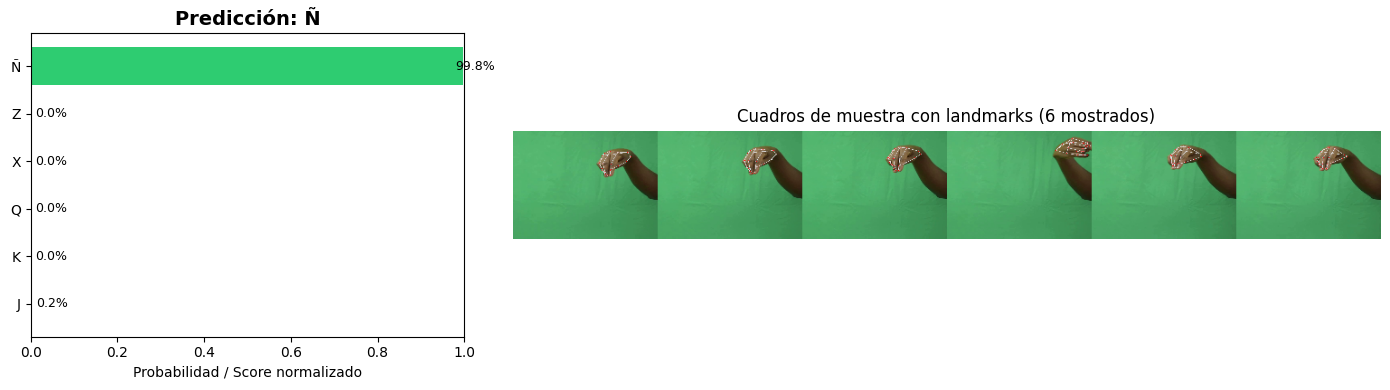

In [43]:
# ============================================================
# PASO 16. DIÁLOGO DE SELECCIÓN DE ARCHIVO
# ============================================================

import tkinter as tk
from tkinter import filedialog

root = tk.Tk()
root.withdraw()                    # Ocultar ventana raíz de tkinter
root.attributes('-topmost', True)  # Asegurar que el diálogo aparezca al frente

video_path_dialog = filedialog.askopenfilename(
    title="Selecciona un video de seña dinámica",
    filetypes=[("Archivos de video", "*.mp4 *.avi *.mov *.mkv"),
               ("Todos los archivos", "*.*")]
)
root.destroy()

if not video_path_dialog:
    print("⚠️  No se seleccionó ningún archivo.")
else:
    show_prediction_result(video_path_dialog, results[best_name]["model"], scaler)